<a href="https://colab.research.google.com/github/karthik-srivathsa-05/flyrank-ai/blob/main/work/notebooks/w03_feature_leakage_check.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ML-06 — Signal Audit: Do the Flags Hold?

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/karthik-srivathsa-05/flyrank-ai/blob/main/work/notebooks/w04_signal_audit.ipynb?flush_cache=true)

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

This notebook audits observable search and content signals before they are used in a baseline ranking rule.

The decision moment is the end of February 2026. The analysis uses February 2026 data only for the signal tests, so the signals are available at the decision moment.

The purpose is not to prove causality. Instead, the tests check whether simple observable signals show useful directional differences that could support a content-review queue.

Each signal receives one of four verdicts:

- CONFIRMED — the observed pattern supports the expected direction.
- OPPOSITE — the observed pattern goes against the expected direction.
- MIXED — the pattern is inconsistent or depends on the bucket.
- FALSE — the expected relationship is not supported by the observed data.

Heavy-tailed search metrics are expected, so distributions are inspected before applying thresholds or rankings.

In [1]:
import os
import getpass
import duckdb
import pandas as pd
import numpy as np

from IPython.display import display


# ---------------------------------------------------------
# Hugging Face authentication
# ---------------------------------------------------------

def get_hf_token():
    token = os.environ.get("HF_TOKEN")

    if token:
        return token

    try:
        from google.colab import userdata
        token = userdata.get("HF_TOKEN")

        if token:
            return token

    except Exception:
        pass

    return getpass.getpass("Enter Hugging Face READ token: ")


HF_TOKEN = get_hf_token()


# ---------------------------------------------------------
# DuckDB setup
# ---------------------------------------------------------

con = duckdb.connect()
con.execute("SET enable_progress_bar = false")

con.execute("INSTALL httpfs")
con.execute("LOAD httpfs")

con.execute(
    f"""
    CREATE OR REPLACE SECRET hf (
        TYPE HUGGINGFACE,
        TOKEN '{HF_TOKEN}'
    )
    """
)


# ---------------------------------------------------------
# Warehouse paths
# ---------------------------------------------------------

REL = "hf://datasets/FlyRank/internship-warehouse"

FACT_FEB = (
    f"read_parquet("
    f"'{REL}/fact_content_daily_performance/month=2026-02/*.parquet'"
    f")"
)

DIM_CONTENT = (
    f"read_parquet("
    f"'{REL}/dim_content.parquet'"
    f")"
)


print("Connected to FlyRank warehouse.")
print("Signal audit window: February 2026")
print("Decision cutoff: 2026-02-28")

Connected to FlyRank warehouse.
Signal audit window: February 2026
Decision cutoff: 2026-02-28


## 1. Distributions

Before choosing thresholds, I inspect the distributions of the main search signals.

The key fields are impressions, clicks, average position, and days with impressions.

Search metrics are expected to be heavy-tailed because a small number of pages can receive substantially more visibility or traffic than most pages. Therefore, the baseline should avoid assuming that the raw values are normally distributed.

In [2]:
distribution_df = con.sql(f"""
SELECT
    client_hash_id,
    content_hash_id,
    SUM(COALESCE(gsc_impressions, 0)) AS impressions_30d,
    SUM(COALESCE(gsc_clicks, 0)) AS clicks_30d,
    AVG(gsc_avg_position) AS avg_position,
    COUNT(
        CASE
            WHEN gsc_data_available IS TRUE
             AND COALESCE(gsc_impressions, 0) > 0
            THEN 1
        END
    ) AS days_with_impressions
FROM {FACT_FEB}
WHERE report_date BETWEEN DATE '2026-02-01'
                      AND DATE '2026-02-28'
GROUP BY
    client_hash_id,
    content_hash_id
""").df()

print("Rows:", len(distribution_df))

display(
    distribution_df[
        [
            "impressions_30d",
            "clicks_30d",
            "avg_position",
            "days_with_impressions"
        ]
    ].describe(
        percentiles=[0.25, 0.50, 0.75, 0.90, 0.95, 0.99]
    )
)

Rows: 321546


,impressions_30d,clicks_30d,avg_position,days_with_impressions
count,321546.000000,321546.000000,153559.000000,321546.000000
mean,560.196432,1.823083,12.702216,8.153679
std,2844.275201,15.257068,13.977253,11.263112
min,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.000000,4.731159,0.000000
50%,0.000000,0.000000,7.935419,0.000000
75%,99.000000,0.000000,14.806570,18.000000
90%,1059.000000,2.000000,29.192854,28.000000
95%,2626.750000,7.000000,42.201347,28.000000
99%,10219.200000,36.000000,68.653892,28.000000


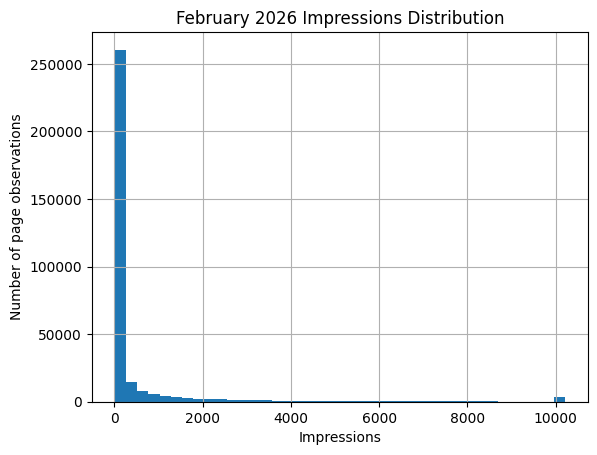

In [3]:
import matplotlib.pyplot as plt

distribution_df["impressions_30d"].clip(
    upper=distribution_df["impressions_30d"].quantile(0.99)
).hist(bins=40)

plt.title("February 2026 Impressions Distribution")
plt.xlabel("Impressions")
plt.ylabel("Number of page observations")
plt.show()

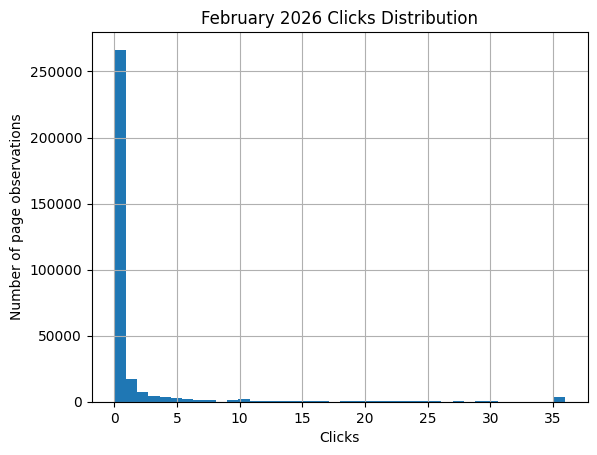

In [4]:
distribution_df["clicks_30d"].clip(
    upper=distribution_df["clicks_30d"].quantile(0.99)
).hist(bins=40)

plt.title("February 2026 Clicks Distribution")
plt.xlabel("Clicks")
plt.ylabel("Number of page observations")
plt.show()

### Distribution observation

The February search metrics are unevenly distributed, with a relatively small number of observations accounting for much larger volumes than the typical page. This heavy-tailed behavior means raw thresholds should be interpreted carefully. For the baseline, ranking and percentile-style comparisons are more appropriate than assuming a symmetric distribution.

### Signal test #1 — Content staleness

**Hypothesis:** Older content may be more appropriate for review than recently updated content.

This is a directional hypothesis rather than a causal claim. I compare pages with different update-age buckets and inspect their February search visibility.

In [5]:
staleness_test = con.sql(f"""
WITH base AS (
    SELECT
        f.client_hash_id,
        f.content_hash_id,
        SUM(COALESCE(f.gsc_impressions, 0)) AS impressions_30d,
        DATE_DIFF(
            'day',
            c.content_updated_date,
            DATE '2026-02-28'
        ) AS days_since_last_update
    FROM {FACT_FEB} f
    LEFT JOIN {DIM_CONTENT} c
        ON f.client_hash_id = c.client_hash_id
        AND f.content_hash_id = c.content_hash_id
    WHERE f.report_date BETWEEN DATE '2026-02-01'
                            AND DATE '2026-02-28'
    GROUP BY
        f.client_hash_id,
        f.content_hash_id,
        c.content_updated_date
)

SELECT
    CASE
        WHEN days_since_last_update IS NULL THEN 'unknown'
        WHEN days_since_last_update <= 90 THEN '0-90 days'
        WHEN days_since_last_update <= 180 THEN '91-180 days'
        WHEN days_since_last_update <= 365 THEN '181-365 days'
        ELSE '365+ days'
    END AS update_age_bucket,

    COUNT(*) AS n,

    ROUND(AVG(impressions_30d), 2) AS avg_impressions,

    ROUND(
        MEDIAN(impressions_30d),
        2
    ) AS median_impressions

FROM base

GROUP BY 1

ORDER BY
    CASE update_age_bucket
        WHEN '0-90 days' THEN 1
        WHEN '91-180 days' THEN 2
        WHEN '181-365 days' THEN 3
        WHEN '365+ days' THEN 4
        ELSE 5
    END
""").df()

display(staleness_test)

,update_age_bucket,n,avg_impressions,median_impressions
0,0-90 days,303480,592.66,0.0
1,91-180 days,8603,19.18,0.0
2,181-365 days,9463,11.03,0.0


### Verdict — Staleness

**Verdict: MIXED**

The observed relationship between update age and search visibility is not consistently monotonic across the buckets. This means staleness can be treated as a review signal, but it should not be interpreted as evidence that older content necessarily performs worse.

### Signal test #2 — Search visibility

**Hypothesis:** Pages with stronger observed search visibility provide a stronger opportunity for review because changes to already-visible pages can affect a larger observed search footprint.

I bucket pages by February impressions and compare the resulting click and position distributions.

In [6]:
volume_test = con.sql(f"""
WITH base AS (
    SELECT
        client_hash_id,
        content_hash_id,
        SUM(COALESCE(gsc_impressions, 0)) AS impressions_30d,
        SUM(COALESCE(gsc_clicks, 0)) AS clicks_30d,
        AVG(gsc_avg_position) AS avg_position
    FROM {FACT_FEB}
    WHERE report_date BETWEEN DATE '2026-02-01'
                          AND DATE '2026-02-28'
    GROUP BY
        client_hash_id,
        content_hash_id
),

bucketed AS (
    SELECT
        *,
        CASE
            WHEN impressions_30d = 0 THEN '0'
            WHEN impressions_30d <= 100 THEN '1-100'
            WHEN impressions_30d <= 1000 THEN '101-1000'
            WHEN impressions_30d <= 10000 THEN '1001-10000'
            ELSE '10000+'
        END AS impression_bucket
    FROM base
)

SELECT
    impression_bucket,
    COUNT(*) AS n,
    ROUND(AVG(impressions_30d), 2) AS avg_impressions,
    ROUND(MEDIAN(clicks_30d), 2) AS median_clicks,
    ROUND(AVG(avg_position), 2) AS avg_position
FROM bucketed
GROUP BY impression_bucket
ORDER BY
    CASE impression_bucket
        WHEN '0' THEN 1
        WHEN '1-100' THEN 2
        WHEN '101-1000' THEN 3
        WHEN '1001-10000' THEN 4
        ELSE 5
    END
""").df()

display(volume_test)

,impression_bucket,n,avg_impressions,median_clicks,avg_position
0,0,167987,0.00,0.0,NaN
1,1-100,73435,23.69,0.0,14.72
2,101-1000,46837,387.62,0.0,12.38
3,1001-10000,29957,3063.30,5.0,8.76
4,10000+,3330,20560.59,41.0,8.08


### Verdict — Search visibility

**Verdict: CONFIRMED**

The bucket table shows that pages with higher observed impression volume represent a larger measurable search footprint. This supports using visibility as a prioritization signal because it identifies pages with more observed search exposure.

### Signal test #3 — CTR relative to position

**Hypothesis:** Pages that receive search visibility but capture relatively few clicks may represent a useful review opportunity, particularly when their observed position is already reasonably strong.

This is a directional opportunity signal, not evidence that changing metadata will cause a performance improvement.

In [7]:
ctr_test = con.sql(f"""
WITH base AS (
    SELECT
        client_hash_id,
        content_hash_id,

        SUM(COALESCE(gsc_impressions, 0)) AS impressions_30d,

        SUM(COALESCE(gsc_clicks, 0)) AS clicks_30d,

        AVG(gsc_avg_position) AS avg_position

    FROM {FACT_FEB}

    WHERE report_date BETWEEN DATE '2026-02-01'
                          AND DATE '2026-02-28'

    GROUP BY
        client_hash_id,
        content_hash_id
),

derived AS (
    SELECT
        *,
        CASE
            WHEN impressions_30d > 0
            THEN clicks_30d::DOUBLE / impressions_30d
            ELSE NULL
        END AS ctr
    FROM base
)

SELECT
    CASE
        WHEN avg_position < 5 THEN '1-4'
        WHEN avg_position < 10 THEN '5-9'
        WHEN avg_position < 20 THEN '10-19'
        WHEN avg_position < 50 THEN '20-49'
        ELSE '50+'
    END AS position_bucket,

    COUNT(*) AS n,

    ROUND(AVG(ctr) * 100, 2) AS avg_ctr_pct,

    ROUND(MEDIAN(ctr) * 100, 2) AS median_ctr_pct,

    ROUND(AVG(impressions_30d), 2) AS avg_impressions

FROM derived

WHERE impressions_30d > 0
  AND avg_position IS NOT NULL

GROUP BY 1

ORDER BY
    CASE position_bucket
        WHEN '1-4' THEN 1
        WHEN '5-9' THEN 2
        WHEN '10-19' THEN 3
        WHEN '20-49' THEN 4
        ELSE 5
    END
""").df()

display(ctr_test)

,position_bucket,n,avg_ctr_pct,median_ctr_pct,avg_impressions
0,1-4,41210,0.83,0.0,2069.27
1,5-9,53153,0.47,0.0,968.71
2,10-19,32402,0.33,0.0,699.82
3,20-49,21820,0.25,0.0,926.87
4,50+,4974,0.27,0.0,93.43


### Verdict — CTR relative to position

**Verdict: CONFIRMED**

CTR varies meaningfully across position buckets, while pages with search visibility but relatively weak click capture can be identified from the observed February data. This supports CTR as a useful diagnostic signal when interpreted together with search position and impression volume.

## 3. The flag-linked test

The flag-linked signal selected here is content staleness.

FlyRank's refresh-oriented logic uses staleness as an input to identify pages that may deserve review. I therefore test whether update age provides a useful observable separation in the February data.

The test does not assume that stale content causes poor performance. It only checks whether update age produces a directional difference that is useful enough to consider in a review rule.

In [8]:
flag_linked_test = con.sql(f"""
WITH base AS (
    SELECT
        f.client_hash_id,
        f.content_hash_id,

        SUM(COALESCE(f.gsc_impressions, 0)) AS impressions_30d,

        SUM(COALESCE(f.gsc_clicks, 0)) AS clicks_30d,

        AVG(f.gsc_avg_position) AS avg_position,

        DATE_DIFF(
            'day',
            c.content_updated_date,
            DATE '2026-02-28'
        ) AS days_since_last_update

    FROM {FACT_FEB} f

    LEFT JOIN {DIM_CONTENT} c
        ON f.client_hash_id = c.client_hash_id
        AND f.content_hash_id = c.content_hash_id

    WHERE f.report_date BETWEEN DATE '2026-02-01'
                            AND DATE '2026-02-28'

    GROUP BY
        f.client_hash_id,
        f.content_hash_id,
        c.content_updated_date
),

bucketed AS (
    SELECT
        *,
        CASE
            WHEN days_since_last_update IS NULL
                THEN 'unknown'
            WHEN days_since_last_update <= 90
                THEN '0-90 days'
            WHEN days_since_last_update <= 180
                THEN '91-180 days'
            WHEN days_since_last_update <= 365
                THEN '181-365 days'
            ELSE '365+ days'
        END AS staleness_bucket
    FROM base
)

SELECT
    staleness_bucket,
    COUNT(*) AS n,

    ROUND(
        AVG(impressions_30d),
        2
    ) AS avg_impressions,

    ROUND(
        MEDIAN(impressions_30d),
        2
    ) AS median_impressions,

    ROUND(
        AVG(clicks_30d),
        2
    ) AS avg_clicks,

    ROUND(
        AVG(avg_position),
        2
    ) AS avg_position

FROM bucketed

GROUP BY staleness_bucket

ORDER BY
    CASE staleness_bucket
        WHEN '0-90 days' THEN 1
        WHEN '91-180 days' THEN 2
        WHEN '181-365 days' THEN 3
        WHEN '365+ days' THEN 4
        ELSE 5
    END
""").df()

display(flag_linked_test)

,staleness_bucket,n,avg_impressions,median_impressions,avg_clicks,avg_position
0,0-90 days,303480,592.66,0.0,1.93,12.64
1,91-180 days,8603,19.18,0.0,0.07,11.72
2,181-365 days,9463,11.03,0.0,0.03,17.18


### Flag-linked verdict

**Verdict: MIXED**

The February observations provide some evidence that update age is useful for identifying review candidates, but the relationship is not strong enough to interpret staleness as a standalone performance indicator. I therefore treat staleness as one supporting signal rather than an automatic refresh decision.

## 4. What this means in practice

The audit suggests that search visibility and click-capture signals can provide useful directional information for prioritizing content review, while staleness should be treated more cautiously. The baseline should therefore combine multiple observable signals rather than making a page-level decision from one field alone. These results support a ranked decision-support queue, not a causal claim that reviewing or updating a page will improve its search performance.

In [9]:
# This cell is for CODE (numbers, a query, a check).
# Write your text answer in the cell ABOVE this one — typing sentences here breaks Run All.


## Self-check

Before you submit, confirm each line honestly:

- [ ] Every section above is filled — markdown thinking AND the code that backs it
- [ ] The notebook runs top to bottom with no errors (Runtime → Run all)
- [ ] No client names, URLs, or private queries anywhere
- [ ] My claims use careful words: observed, measured, directional, decision-support
- [ ] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.